In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

In [2]:
song_features = pd.read_csv("../data/song_features_processed.csv")

titles = song_features["Title"]
X = song_features.drop(columns=["Title"])

**Feature Scaling**  
All numeric features were standardized during the preprocessing step using StandardScaler. The modeling notebook uses the pre-scaled feature set directly to avoid double scaling.

In [3]:
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

**Model Choice and Evaluation**  
Since we are doing unsupervised learning, silhouette score will be used as the primary evaluation metric. This measures both cluster cohesion and separation without requiring labeled data.  

Three clustering algorithms will be explored: K-Means, Agglomerative Clustering, and Gaussian Mixture Models.

In [4]:
k_values = range(2, 9)
kmeans_train_scores = {}

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_train)
    kmeans_train_scores[k] = silhouette_score(X_train, labels)

kmeans_train_scores

{2: np.float64(0.18798536331869603),
 3: np.float64(0.1342779064705714),
 4: np.float64(0.1342939360657563),
 5: np.float64(0.11153899136153195),
 6: np.float64(0.1092757990244256),
 7: np.float64(0.12692743988362254),
 8: np.float64(0.1213646025199016)}

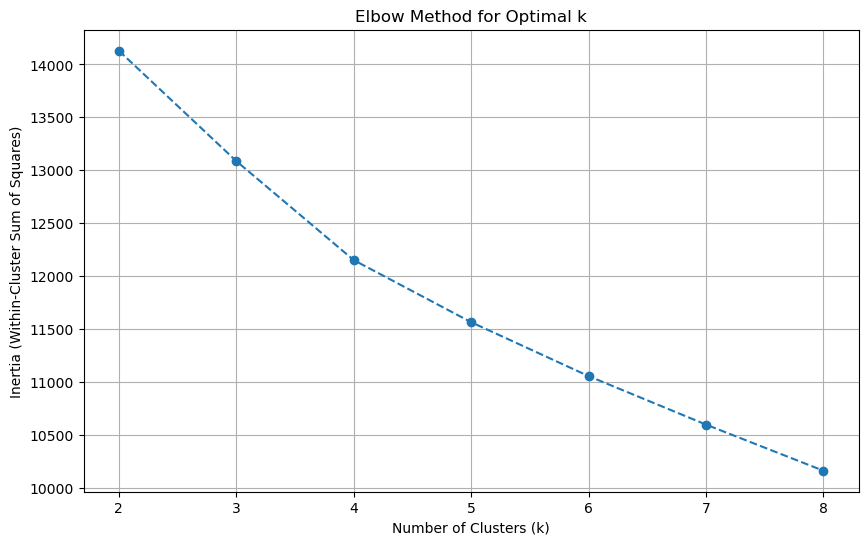

In [5]:
inertias = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    kmeans.fit(X_train)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_values, inertias, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [6]:
pip install yellowbrick

Note: you may need to restart the kernel to use updated packages.


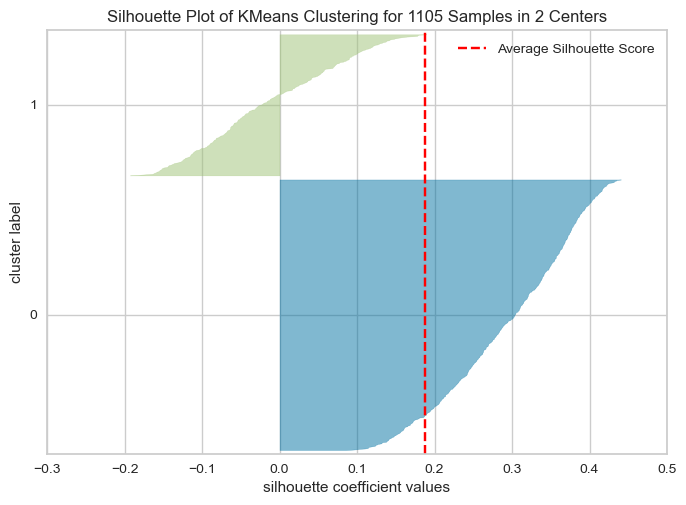

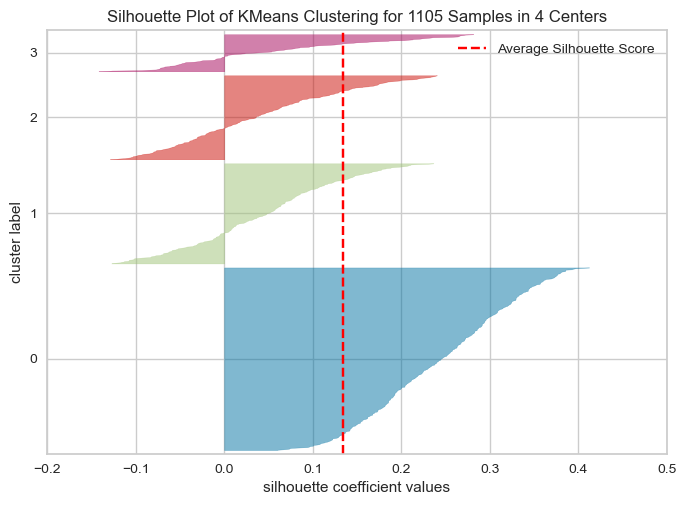

In [7]:
from yellowbrick.cluster import SilhouetteVisualizer

# Compare k=2 and k=4
for k in [2, 4]:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    visualizer = SilhouetteVisualizer(model, colors='yellowbrick')
    visualizer.fit(X_train)
    visualizer.show()

In [8]:
best_k = 4

In [9]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

kmeans_train_labels = kmeans.fit_predict(X_train)
kmeans_test_labels = kmeans.predict(X_test)

kmeans_train_sil = silhouette_score(X_train, kmeans_train_labels)
kmeans_test_sil = silhouette_score(X_test, kmeans_test_labels)

kmeans_train_sil, kmeans_test_sil

(np.float64(0.1342939360657563), np.float64(0.13478898741051057))

In [10]:
agg = AgglomerativeClustering(
    n_clusters=best_k,
    linkage="ward"
)

agg_train_labels = agg.fit_predict(X_train)
agg_test_labels = agg.fit_predict(X_test)

agg_train_sil = silhouette_score(X_train, agg_train_labels)
agg_test_sil = silhouette_score(X_test, agg_test_labels)

agg_train_sil, agg_test_sil

(np.float64(0.06976533651531168), np.float64(0.09816926873069413))

In [11]:
gmm_train_scores = {}

for k in k_values:
    gmm = GaussianMixture(
        n_components=k,
        random_state=42
    )
    labels = gmm.fit_predict(X_train)
    gmm_train_scores[k] = silhouette_score(X_train, labels)

gmm_train_scores

{2: np.float64(0.16995866687861633),
 3: np.float64(0.10638187951186381),
 4: np.float64(0.10248759601035236),
 5: np.float64(0.067783858704592),
 6: np.float64(0.07020018202293013),
 7: np.float64(0.0599038537218893),
 8: np.float64(0.018765816608718757)}

In [12]:
best_gmm_k = max(gmm_train_scores, key=gmm_train_scores.get)
best_gmm_k

2

In [13]:
gmm = GaussianMixture(
    n_components=best_gmm_k,
    random_state=42
)

gmm_train_labels = gmm.fit_predict(X_train)
gmm_test_labels = gmm.predict(X_test)

gmm_train_sil = silhouette_score(X_train, gmm_train_labels)
gmm_test_sil = silhouette_score(X_test, gmm_test_labels)

gmm_train_sil, gmm_test_sil

(np.float64(0.16995866687861633), np.float64(0.10996873945162483))

In [14]:
model_comparison = pd.DataFrame({
    "Model": ["KMeans", "Agglomerative", "GMM"],
    "Train Silhouette": [
        kmeans_train_sil,
        agg_train_sil,
        gmm_train_sil
    ],
    "Test Silhouette": [
        kmeans_test_sil,
        agg_test_sil,
        gmm_test_sil
    ]
})

model_comparison.sort_values("Test Silhouette", ascending=False)

,Model,Train Silhouette,Test Silhouette
0,KMeans,0.134294,0.134789
2,GMM,0.169959,0.109969
1,Agglomerative,0.069765,0.098169


**Results**  
The silhouette scores across all models are modest, indicating overlapping clusters. This is expected given the high dimensionality of the feature space and the stylistic continuity of jazz standards. Music style does not exhibit sharply separable boundaries, and many songs share characteristics across harmonic and rhythmic dimensions.

Despite this, both KMeans and Agglomerative Clustering show consistent performance on unseen data, suggesting stable and meaningful structure. KMeans was selected as the final model due to its slightly higher and more consistent silhouette scores, interpretability, and lower computational complexity.

**We will now explore the clusters**

In [15]:
final_clusters = song_features.copy()

final_clusters.loc[X_train.index, "cluster"] = kmeans_train_labels
final_clusters.loc[X_test.index, "cluster"] = kmeans_test_labels

In [16]:
final_clusters["cluster"].isna().sum()

np.int64(0)

In [17]:
final_clusters.head()

,Title,n_chords,n_measures,chords_per_measure,pct_triad,pct_maj7,pct_m7,pct_dominant,pct_diminished,pct_extensions_9plus,...,Key_Ebmin,Key_Emin,Key_F,Key_F#min,Key_Fmin,Key_G,Key_G#min,Key_Gb,Key_Gmin,cluster
0,26-2,1.244329,-0.913729,2.102109,-0.897150,2.032590,-0.643598,0.410345,-0.914208,-0.716949,...,False,False,True,False,False,False,False,False,False,0.0
1,500 Miles High,-1.321162,0.999274,-1.394632,-0.897150,0.394162,2.166027,-1.502324,1.305757,0.103649,...,False,True,False,False,False,False,False,False,False,1.0
2,502 Blues,-1.321162,1.381874,-1.465534,-0.897150,0.771260,0.202674,-0.445802,2.045745,0.650714,...,False,False,False,False,False,False,False,False,False,1.0
3,52nd Street Theme,-0.180944,-0.913729,0.651848,0.881320,-1.114233,0.512677,-0.153868,-0.914208,-0.716949,...,False,False,False,False,False,False,False,False,False,0.0
4,9.20 Special,-0.252207,-0.531128,0.042738,1.690444,-1.114233,-1.760678,0.689245,-0.914208,0.421538,...,False,False,False,False,False,False,False,False,False,2.0


In [18]:
final_clusters.dtypes

Title                      object
n_chords                  float64
n_measures                float64
chords_per_measure        float64
pct_triad                 float64
pct_maj7                  float64
pct_m7                    float64
pct_dominant              float64
pct_diminished            float64
pct_extensions_9plus      float64
mean_root_motion          float64
pct_desc_fifth            float64
root_pc_entropy           float64
Year                      float64
Rhythm_Ballad                bool
Rhythm_Bossa Nova            bool
Rhythm_Calypso               bool
Rhythm_Even 16ths            bool
Rhythm_Even 8ths             bool
Rhythm_Funk                  bool
Rhythm_Latin                 bool
Rhythm_Latin-Swing           bool
Rhythm_Medium Slow           bool
Rhythm_Medium Swing          bool
Rhythm_Medium Up Swing       bool
Rhythm_Rock Pop              bool
Rhythm_Samba                 bool
Rhythm_Slow Rock             bool
Rhythm_Slow Swing            bool
Rhythm_Up Temp

In [19]:
numeric_scaled_cols = [
    "n_chords", "n_measures", "chords_per_measure",
    "pct_triad", "pct_maj7", "pct_m7", "pct_dominant", "pct_diminished",
    "pct_extensions_9plus", "mean_root_motion", "pct_desc_fifth", "root_pc_entropy", "Year"
]

categorical_cols = final_clusters.select_dtypes(include='bool').columns.tolist()

In [20]:
import joblib

scaler = joblib.load("scaler.pkl")

In [21]:
final_clusters_unscaled = final_clusters.copy()

# Inverse transform numeric columns
final_clusters_unscaled[numeric_scaled_cols] = scaler.inverse_transform(
    final_clusters[numeric_scaled_cols]
)

final_clusters_unscaled["cluster"] = final_clusters_unscaled["cluster"].astype(int)

final_clusters_unscaled.head()

,Title,n_chords,n_measures,chords_per_measure,pct_triad,pct_maj7,pct_m7,pct_dominant,pct_diminished,pct_extensions_9plus,...,Key_Ebmin,Key_Emin,Key_F,Key_F#min,Key_Fmin,Key_G,Key_G#min,Key_Gb,Key_Gmin,cluster
0,26-2,58.0,8.0,7.250000,0.000000,0.379310,0.155172,0.465517,0.000000,0.000000,...,False,False,True,False,False,False,False,False,False,0
1,500 Miles High,22.0,18.0,1.222222,0.000000,0.181818,0.545455,0.136364,0.136364,0.136364,...,False,True,False,False,False,False,False,False,False,1
2,502 Blues,22.0,20.0,1.100000,0.000000,0.227273,0.272727,0.318182,0.181818,0.227273,...,False,False,False,False,False,False,False,False,False,1
3,52nd Street Theme,38.0,8.0,4.750000,0.315789,0.000000,0.315789,0.368421,0.000000,0.000000,...,False,False,False,False,False,False,False,False,False,0
4,9.20 Special,37.0,10.0,3.700000,0.459459,0.000000,0.000000,0.513514,0.000000,0.189189,...,False,False,False,False,False,False,False,False,False,2


In [22]:
cluster_numeric_means = (
    final_clusters_unscaled
    .groupby("cluster")[numeric_scaled_cols]
    .mean()
)

cluster_categorical_props = (
    final_clusters_unscaled
    .groupby("cluster")[categorical_cols]
    .mean()
)

cluster_summary = pd.concat(
    [cluster_numeric_means, cluster_categorical_props],
    axis=1
)

cluster_summary.head()

,n_chords,n_measures,chords_per_measure,pct_triad,pct_maj7,pct_m7,pct_dominant,pct_diminished,pct_extensions_9plus,mean_root_motion,...,Key_Eb,Key_Ebmin,Key_Emin,Key_F,Key_F#min,Key_Fmin,Key_G,Key_G#min,Key_Gb,Key_Gmin
cluster,,,,,,,,,,,,,,,,,,,,,
0,47.630265,10.051482,4.918504,0.112223,0.128546,0.285289,0.395159,0.064562,0.078544,3.748687,...,0.209048,0.004680,0.003120,0.209048,0.00156,0.017161,0.102964,0.000000,0.000000,0.009360
1,38.101449,17.721739,2.304698,0.098531,0.212944,0.303389,0.320839,0.058332,0.113682,2.955703,...,0.118841,0.011594,0.017391,0.165217,0.00000,0.020290,0.069565,0.002899,0.002899,0.023188
2,29.971530,12.263345,2.682956,0.203827,0.048367,0.129786,0.564830,0.043651,0.072041,3.049587,...,0.096085,0.003559,0.003559,0.188612,0.00000,0.035587,0.071174,0.003559,0.000000,0.017794
3,34.147826,14.382609,2.693836,0.495210,0.140497,0.121666,0.200426,0.033331,0.476875,2.348021,...,0.052174,0.026087,0.026087,0.086957,0.00000,0.069565,0.069565,0.000000,0.000000,0.069565


In [23]:
cluster_summary[
    [
        "n_chords",
        "pct_maj7",
        "pct_m7",
        "pct_dominant",
        "pct_diminished",
        "pct_extensions_9plus",
        "mean_root_motion",
        "pct_desc_fifth",
        "Year"
    ]
]

,n_chords,pct_maj7,pct_m7,pct_dominant,pct_diminished,pct_extensions_9plus,mean_root_motion,pct_desc_fifth,Year
cluster,,,,,,,,,
0,47.630265,0.128546,0.285289,0.395159,0.064562,0.078544,3.748687,0.594557,1942.862680
1,38.101449,0.212944,0.303389,0.320839,0.058332,0.113682,2.955703,0.417662,1953.561761
2,29.971530,0.048367,0.129786,0.564830,0.043651,0.072041,3.049587,0.477162,1941.368288
3,34.147826,0.140497,0.121666,0.200426,0.033331,0.476875,2.348021,0.276853,1962.089727


In [24]:
cluster_summary[
    categorical_cols
]

,Rhythm_Ballad,Rhythm_Bossa Nova,Rhythm_Calypso,Rhythm_Even 16ths,Rhythm_Even 8ths,Rhythm_Funk,Rhythm_Latin,Rhythm_Latin-Swing,Rhythm_Medium Slow,Rhythm_Medium Swing,...,Key_Eb,Key_Ebmin,Key_Emin,Key_F,Key_F#min,Key_Fmin,Key_G,Key_G#min,Key_Gb,Key_Gmin
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.321373,0.020281,0.000000,0.000000,0.006240,0.000000,0.010920,0.00156,0.000000,0.413417,...,0.209048,0.004680,0.003120,0.209048,0.00156,0.017161,0.102964,0.000000,0.000000,0.009360
1,0.084058,0.133333,0.000000,0.000000,0.040580,0.008696,0.020290,0.00000,0.000000,0.286957,...,0.118841,0.011594,0.017391,0.165217,0.00000,0.020290,0.069565,0.002899,0.002899,0.023188
2,0.092527,0.010676,0.003559,0.000000,0.017794,0.021352,0.056940,0.00000,0.007117,0.427046,...,0.096085,0.003559,0.003559,0.188612,0.00000,0.035587,0.071174,0.003559,0.000000,0.017794
3,0.104348,0.069565,0.000000,0.008696,0.113043,0.026087,0.043478,0.00000,0.000000,0.191304,...,0.052174,0.026087,0.026087,0.086957,0.00000,0.069565,0.069565,0.000000,0.000000,0.069565


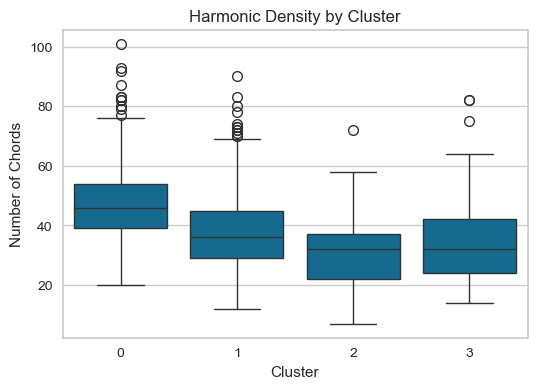

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.boxplot(
    data=final_clusters_unscaled,
    x="cluster",
    y="n_chords"
)
plt.title("Harmonic Density by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Chords")
plt.show()

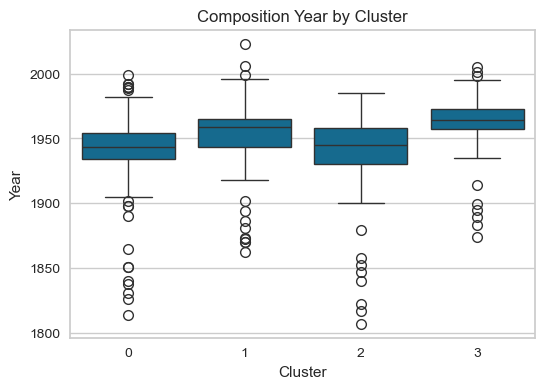

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.boxplot(
    data=final_clusters_unscaled,
    x="cluster",
    y="Year"
)
plt.title("Composition Year by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Year")
plt.show()

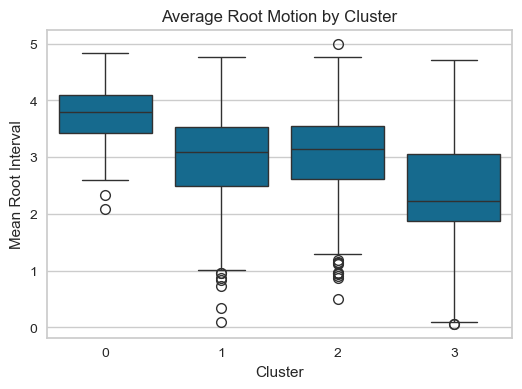

In [27]:
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=final_clusters_unscaled,
    x="cluster",
    y="mean_root_motion"
)
plt.title("Average Root Motion by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Mean Root Interval")
plt.show()

In [28]:
rhythm_cols = [col for col in final_clusters.columns if col.startswith("Rhythm_")]

rhythm_summary = (
    final_clusters
    .groupby("cluster")[rhythm_cols]
    .mean()
    .T
)

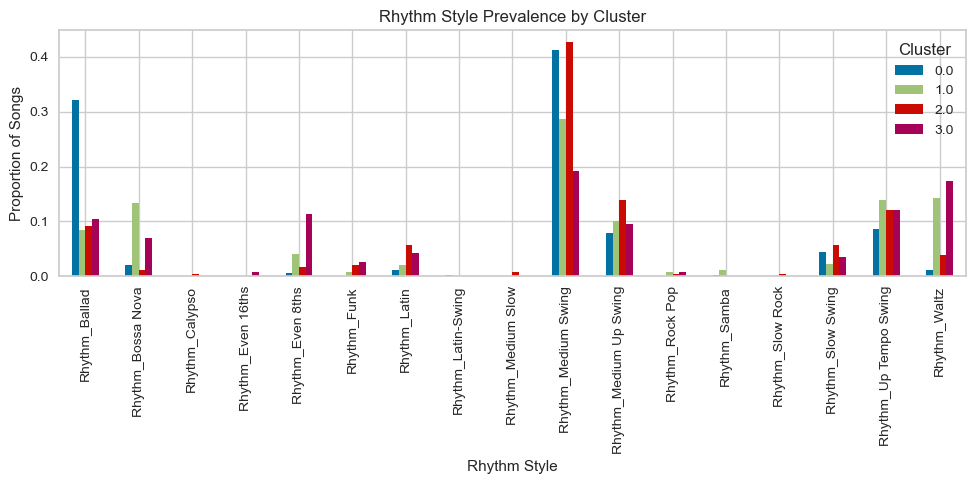

In [29]:
rhythm_summary.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Rhythm Style Prevalence by Cluster")
plt.ylabel("Proportion of Songs")
plt.xlabel("Rhythm Style")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

In [30]:
key_cols = [col for col in final_clusters.columns if col.startswith("Key_")]

key_summary = (
    final_clusters
    .groupby("cluster")[key_cols]
    .mean()
    .T
)

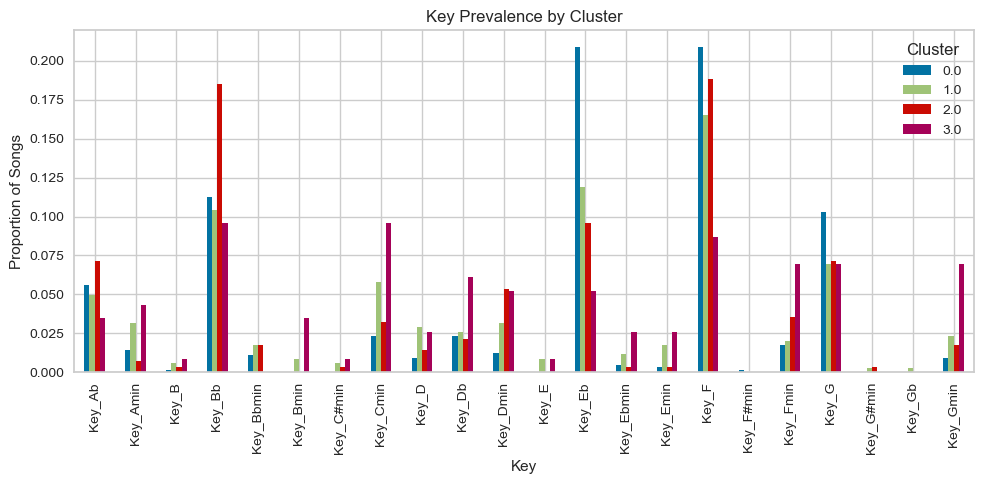

In [31]:
key_summary.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Key Prevalence by Cluster")
plt.ylabel("Proportion of Songs")
plt.xlabel("Key")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

In [32]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=X.index
)

pca_df["cluster"] = final_clusters["cluster"]

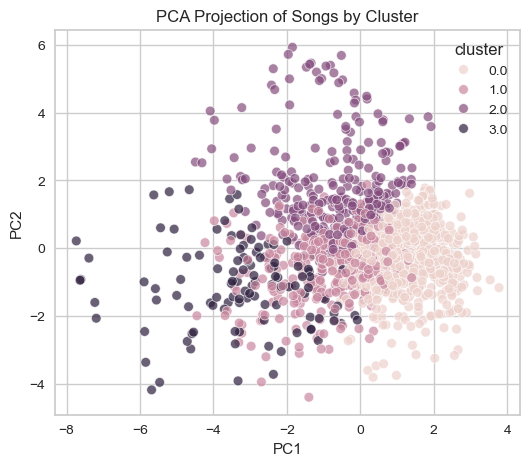

In [33]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    alpha=0.7
)
plt.title("PCA Projection of Songs by Cluster")
plt.show()

In [34]:
df = final_clusters_unscaled.copy()

# Collapse Rhythm columns
rhythm_cols = [col for col in df.columns if col.startswith("Rhythm_")]
df["Rhythm"] = df[rhythm_cols].idxmax(axis=1).str.replace("Rhythm_", "")

# Collapse TimeSignature columns
ts_cols = [col for col in df.columns if col.startswith("TimeSignature_")]
df["TimeSignature"] = df[ts_cols].idxmax(axis=1).str.replace("TimeSignature_", "")

# Drop the original dummy columns
df = df.drop(columns=rhythm_cols + ts_cols)

final_clusters_unscaled_collapsed = df

final_clusters_unscaled_collapsed.head()

,Title,n_chords,n_measures,chords_per_measure,pct_triad,pct_maj7,pct_m7,pct_dominant,pct_diminished,pct_extensions_9plus,...,Key_F,Key_F#min,Key_Fmin,Key_G,Key_G#min,Key_Gb,Key_Gmin,cluster,Rhythm,TimeSignature
0,26-2,58.0,8.0,7.250000,0.000000,0.379310,0.155172,0.465517,0.000000,0.000000,...,True,False,False,False,False,False,False,0,Medium Up Swing,4/4
1,500 Miles High,22.0,18.0,1.222222,0.000000,0.181818,0.545455,0.136364,0.136364,0.136364,...,False,False,False,False,False,False,False,1,Bossa Nova,4/4
2,502 Blues,22.0,20.0,1.100000,0.000000,0.227273,0.272727,0.318182,0.181818,0.227273,...,False,False,False,False,False,False,False,1,Waltz,3/4
3,52nd Street Theme,38.0,8.0,4.750000,0.315789,0.000000,0.315789,0.368421,0.000000,0.000000,...,False,False,False,False,False,False,False,0,Up Tempo Swing,4/4
4,9.20 Special,37.0,10.0,3.700000,0.459459,0.000000,0.000000,0.513514,0.000000,0.189189,...,False,False,False,False,False,False,False,2,Medium Swing,4/4


In [35]:
# Peek at first 5 songs per cluster
final_clusters_unscaled_collapsed.sort_values("cluster").groupby("cluster").head(5)[["cluster", "Title", "Year", "Rhythm", "TimeSignature"]]

,cluster,Title,Year,Rhythm,TimeSignature
0,0,26-2,1941.0,Medium Up Swing,4/4
1002,0,Portrait Of Jennie,1948.0,Ballad,4/4
490,0,Here's To My Lady,1951.0,Medium Swing,4/4
491,0,Hey There,1954.0,Medium Swing,4/4
1000,0,Poor Butterfly,1916.0,Ballad,4/4
826,1,Midnight Sun,1939.0,Medium Swing,4/4
1347,1,Yes And No,1964.0,Up Tempo Swing,4/4
1369,1,You're Everything,1972.0,Bossa Nova,4/4
871,1,My Favorite Things,1959.0,Waltz,3/4
815,1,Maybe September,1965.0,Bossa Nova,4/4


## Summary of Differences Between the Four Clusters (k=4)

### Cluster 0: The Traditional "Big Band" Swing Core
* **Average Year:** ~1943 (The "Golden Age" of traditional jazz).
* **Harmonic Density:** **Highest density** with ~48 chords per song.
* **Chord Quality:** Heavy reliance on **Dominant 7ths (40%)** and the highest use of **Diminished chords**.
* **Root Motion:** Most "active" movement; largest average steps (3.7 semitones) and highest downward-fifth movement (~59%).
* **Rhythm:** Overwhelmingly dominated by **Medium Swing** and **Medium Slow Swing**.
* **Profile:** Captures the dense, functional harmony of the 1940s bebop and big band era.

---

### Cluster 1: The "Cool" & Melodic Transition
* **Average Year:** ~1953 (The post-war shift).
* **Harmonic Density:** Moderate (~38 chords).
* **Chord Quality:** Significant rise in **Major 7ths (21%)**, nearly double that of the traditional core.
* **Root Motion:** Smoother and more melodic; average steps drop to ~3.0 semitones.
* **Rhythm:** A "bridge" group; maintains swing but introduces **Bossa Nova**, **Ballads**, and **Up Tempo Swing**.
* **Profile:** Represents a shift toward more "open," melodic, and varied jazz styles.

---

### Cluster 2: The Functional "Blues-Based" Simple Swing
* **Average Year:** ~1941.
* **Harmonic Density:** **Lowest overall density** (~30 chords per song).
* **Chord Quality:** Massive reliance on **Dominant 7ths (56%)**, indicating a "blues-ier" or more structural harmonic approach.
* **Root Motion:** Standard functional motion (~3.0 average steps).
* **Rhythm:** Heavily **Medium Swing**, similar to Cluster 0 but without the harmonic "clutter."
* **Profile:** Captures simpler, more riff-based or standard-heavy repertoire from the early 40s.

---

### Cluster 3: Modern Sophistication 
* **Average Year:** ~1962 (The latest/most modern group).
* **Harmonic Density:** Moderate chord count (~34), but with a specific focus on "color."
* **Chord Quality:** The outlier for complexity; **47% of chords feature Extensions (9ths+)**, far exceeding all other clusters.
* **Root Motion:** The most "linear" or static; smallest average steps (2.3 semitones) and lowest downward-fifth motion (~27%).
* **Rhythm:** The most rhythmic variety; high prevalence of **Waltz**, **Ballad**, and **Even 8ths**.
* **Profile:** Represents the "Modern Jazz" era—sophisticated, extension-heavy, and moving away from traditional swing feels.

### Conclusion
While the $k=2$ model essentially split the data by "Early vs. Late," the **$k=4$** model reveals a more nuanced stylistic breakdown:
* **Clusters 0 & 2** are the **"Traditionalists,"** separated primarily by **Density**.
* **Cluster 1** represents the **Post-War Transition** toward melodic Major 7th sounds.
* **Cluster 3** is the **Modern Outlier**, prioritizing harmonic "color" (extensions) over traditional "drive" (downward fifths/swing).